# Aprendizaje no supervisado

---




## Introducción
El aprendizaje no supervisado es una rama del Machine Learning en la que no contamos con etiquetas o respuestas conocidas. El algoritmo explora los datos y busca patrones, estructuras o agrupaciones por sí solo.

En lugar de decirle al modelo "este es un perro" o "esto es spam", simplemente le mostramos muchos datos y le pedimos que descubra relaciones o grupos interesantes.

| Aspecto             | Supervisado                 | No Supervisado                           |
| ------------------- | --------------------------- | ---------------------------------------- |
| Etiquetas conocidas | ✅ Sí (p. ej., spam/no spam) | ❌ No                                     |
| Objetivo principal  | Predecir una salida         | Descubrir patrones ocultos               |
| Ejemplos comunes    | Clasificación, regresión    | Clustering, reducción de dimensionalidad |
| Tipo de problemas   | Predictivos                 | Exploratorios                            |


---



## Agrupamiento (Clustering)

El **clustering** es una técnica de **aprendizaje no supervisado** que busca agrupar datos similares entre sí sin que haya etiquetas previas.

Imagina que tienes una base de datos con información de personas (edad, ingresos, personalidad, etc.) y no sabes nada más. El clustering agrupa a esas personas según sus similitudes:

- “Estas personas se comportan parecido entre sí”
- “Este grupo tiene características únicas que lo diferencian de los demás”


### ¿Por qué es importante?
- Descubre patrones ocultos en los datos
- Ayuda a segmentar clientes, productos, comportamientos
- Permite crear perfiles incluso cuando no hay etiquetas disponibles
- Ayuda en tareas exploratorias, como detectar anomalías o grupos interesantes



---



### K-Means Clustering
KMeans es un algoritmo que divide los datos en K grupos minimizando la distancia entre los puntos y el centro de cada grupo (centroide).

#### ¿Cómo funciona?
1. Se eligen K puntos aleatorios como centroides iniciales.
2. Cada dato se asigna al centroide más cercano.
3. Se recalculan los centroides como el promedio de los puntos asignados.
4. Se repite hasta que los grupos se estabilizan.

#### Ventajas:

- Simple y rápido
- Funciona bien con datos esféricos o balanceados

#### Limitaciones:

- Hay que elegir K manualmente
- No detecta ruido ni outliers
- Mal desempeño con clusters irregulares

In [29]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
import matplotlib.pyplot as plt
import seaborn as sns


In [30]:
# Generar datos en forma de lunas
X, y = make_moons(n_samples=300, noise=0.08, random_state=42)
X_scaled = StandardScaler().fit_transform(X)

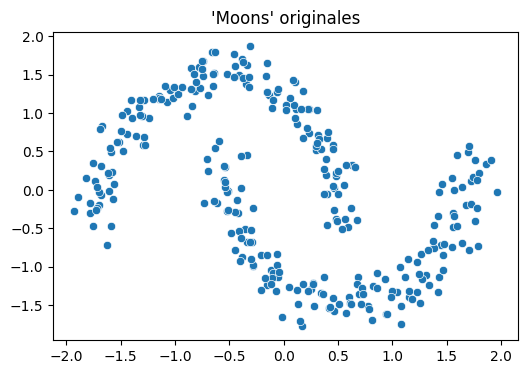

In [31]:
# Visualizar KMeans
plt.figure(figsize=(6, 4))
plt.title("'Moons' originales")
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1])
plt.show()

In [32]:
# KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
labels_kmeans = kmeans.fit_predict(X_scaled)

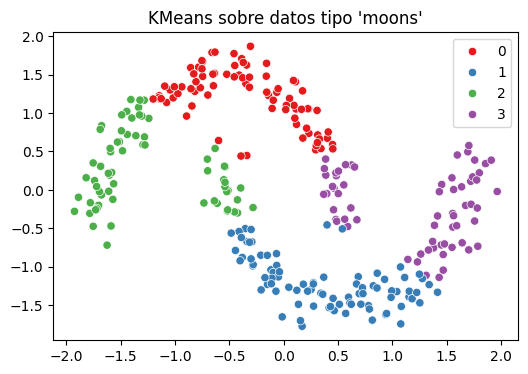

In [33]:
# Visualizar KMeans
plt.figure(figsize=(6, 4))
plt.title("KMeans sobre datos tipo 'moons'")
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=labels_kmeans, palette='Set1')
plt.show()

## KMeans aplicado a flores IRIS

In [64]:
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
# Cargamos el dataset Iris
iris = load_iris()
X = iris.data  # datos (4 variables por flor)
y = iris.target  # etiquetas reales (para colorear los puntos)

# Aplicamos PCA para reducir de 4D a 2D y visualizar los datos
pca = PCA(2)
X_pca = pca.fit_transform(X)

In [98]:
# KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)

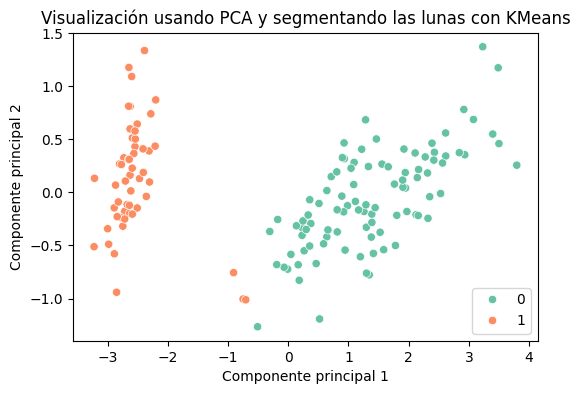

In [99]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], palette='Set2', hue=labels_kmeans)
plt.title('Visualización usando PCA y segmentando las lunas con KMeans')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.show()

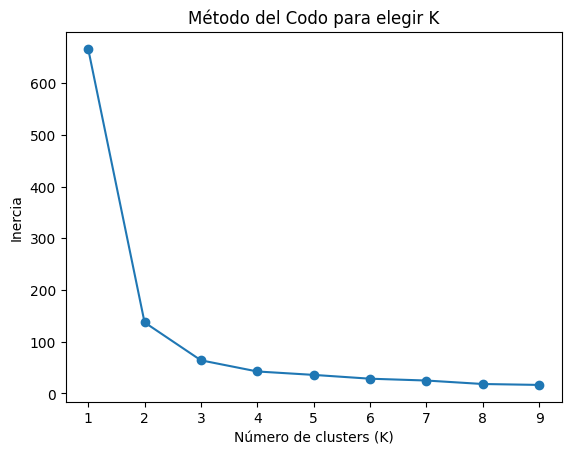

In [ ]:
## METODO DEL CODO
inertias = []
k_range = range(1, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_pca)
    inertias.append(km.inertia_)

plt.plot(k_range, inertias, marker='o')
plt.title('Método del Codo para elegir K')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inercia')
plt.show()


### DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
DBSCAN agrupa datos en regiones densas y deja fuera los puntos aislados o dispersos (considerados ruido).

#### ¿Cómo funciona?
1. Para cada punto, cuenta cuántos vecinos tiene en un radio
2. Si tiene suficientes vecinos, se convierte en punto central de un cluster
3. Agrupa los puntos densamente conectados.
4. Los puntos sin suficientes vecinos se marcan como ruido

#### Ventajas:

- No necesitas decir cuántos grupos hay
- Detecta outliers automáticamente
- Funciona bien con clusters de forma irregular

#### Limitaciones:

- Sensible a la elección del radio y la cantidad mínima de vecinos
- Puede fallar si la densidad de los clusters es muy distinta

In [85]:
# DBSCAN
dbscan = DBSCAN(eps=0.25, min_samples=5)
labels_db = dbscan.fit_predict(X_scaled)

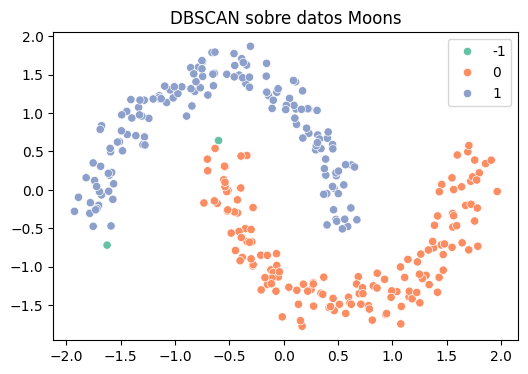

In [87]:
# Visualizar DBSCAN
plt.figure(figsize=(6, 4))
plt.title("DBSCAN sobre datos Moons")
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=labels_db, palette='Set2')
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score
score_dbscan = silhouette_score(X_pca, labels_db)
print(f"Silhouette Score DBSCAN: {score_dbscan:.2f}")

Silhouette Score DBSCAN: 0.40


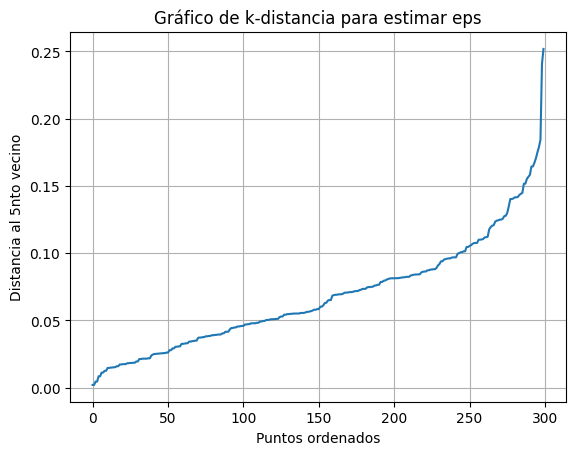

In [80]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, 1])  # distancia al 2NDO vecino

plt.plot(distances)
plt.title('Gráfico de k-distancia para estimar eps')
plt.xlabel('Puntos ordenados')
plt.ylabel('Distancia al 5nto vecino')
plt.grid()
plt.show()


## DBSCAN aplicado a flores IRIS

In [89]:
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
# Cargamos el dataset Iris
iris = load_iris()
X = iris.data  # datos (4 variables por flor)
y = iris.target  # etiquetas reales (para colorear los puntos)

# Aplicamos PCA para reducir de 4D a 2D y visualizar los datos
pca = PCA(2)
X_pca = pca.fit_transform(X)

In [94]:
# DBSCAN
dbscan = DBSCAN(eps=0.20, min_samples=5)
labels_db = dbscan.fit_predict(X_pca)

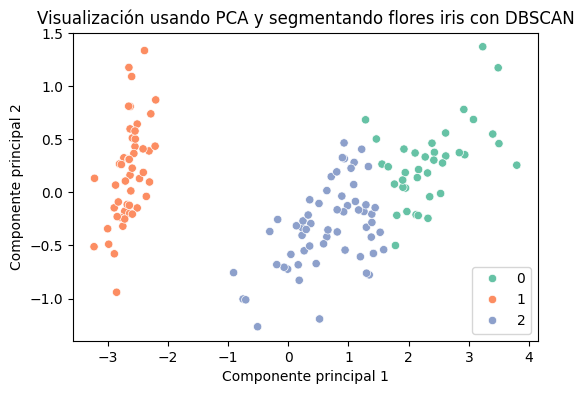

In [97]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], palette='Set2', hue=labels_kmeans)
plt.title('Visualización usando PCA y segmentando flores iris con DBSCAN')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.show()

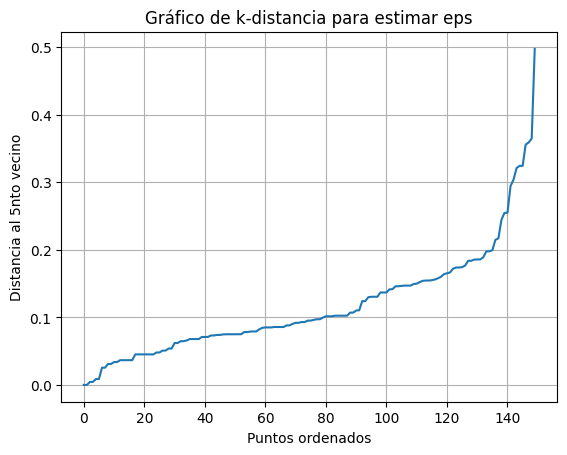

In [93]:
## METODO DEL CODO aplicado a dbscan
from sklearn.neighbors import NearestNeighbors
import numpy as np

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_pca)
distances, indices = neighbors_fit.kneighbors(X_pca)
distances = np.sort(distances[:, 1])  # distancia al 2NDO vecino

plt.plot(distances)
plt.title('Gráfico de k-distancia para estimar eps')
plt.xlabel('Puntos ordenados')
plt.ylabel('Distancia al 5nto vecino')
plt.grid()
plt.show()


### Comparación: KMeans vs DBSCAN
| Característica                    | KMeans                  | DBSCAN                                     |
| --------------------------------- | ----------------------- | ------------------------------------------ |
| ¿Requiere definir nº de clusters? | ✅ Sí (K)                | ❌ No                                       |
| ¿Detecta outliers?                | ❌ No                    | ✅ Sí                                       |
| Forma de los clusters             | Esféricos / balanceados | Irregulares / densos                       |
| Sensible a ruido                  | ✅ Sí                    | ❌ No (puede ignorar ruido)                 |
| Parámetros principales            | `n_clusters` (K)        | `eps`, `min_samples`                       |
| Escalabilidad                     | Muy buena               | Buena para datasets medianos               |
| ¿Apto para visualización?         | ✅ Sí                    | ✅ Sí                                       |
| ¿Recomendado para exploración?    | Solo si conoces la cantidad de grupos       | ✅ Muy útil cuando no conoces la estructura ||


---

